
# Decision Tree: Infogain



In [4]:
import math
import numpy as np

def my_log(val):
  if val == 0:
      return 0
  return math.log2(val)

def entropy(pos_neg):
  pos = pos_neg[0]
  neg = pos_neg[1]
  prob_pos = pos/(pos+neg)
  prob_neg = 1-prob_pos
  pos_part = - prob_pos * my_log(prob_pos)
  neg_part = - prob_neg * my_log(prob_neg)
  entropy = pos_part + neg_part
  return entropy

def infogain (before, after):
  # 1. entropy before split
  total_ent = entropy(before)
  tot_num = before[0] + before[1]
  total_sub = 0
  # 2. entropy after split
  for split in after:
    #
    spilt = split[0] + split[1]
    separate = entropy(split)
    total_sub += (spilt/tot_num) * separate
  info = total_ent - total_sub
  return info

print(entropy([10,10]))
print(entropy([2,5]))

pre = [6,6]
post  = [ [0,2], [4,0], [2,4] ]
print('\n')
print("test")
print(infogain(pre, post))

1.0
0.863120568566631


test
0.5408520829727552


In [5]:
# other tests to run
before = [4,6]
after = [ [1,2], [3,1], [0,3]]
print('\n')
print("Drive")
print(infogain(before, after))
before = [4,6]
after = [[1,5], [3,1]]
print('\n')
print("Body")
print(infogain(before, after))
before = [4,6]
after = [[1,2], [1,2], [2,2]]
print('\n')
print("Price")
print(infogain(before, after))




Drive
0.3709505944546686


Body
0.256425891682003


Price
0.01997309402197489


# Decision Tree


[Text(0.6, 0.8333333333333334, 'x[0] <= 0.5\nentropy = 0.811\nsamples = 4\nvalue = [3, 1]'),
 Text(0.4, 0.5, 'x[3] <= 0.5\nentropy = 1.0\nsamples = 2\nvalue = [1, 1]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6, 0.16666666666666666, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.5, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

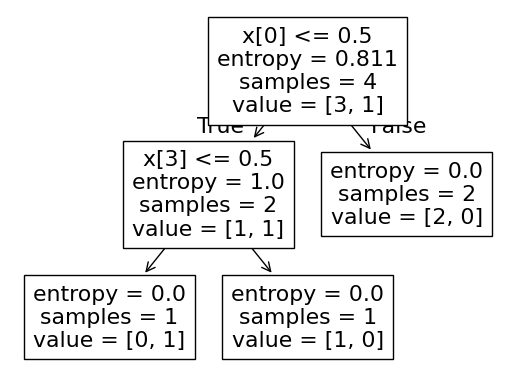

In [6]:
# Testing scikit-learn's decision tree implementation.
#
#  - scikit-learn's decision tree only allows binary target values.

from sklearn import tree
import numpy as np

clf = tree.DecisionTreeClassifier(criterion="entropy")

X = [[0,0,0,0],
     [0,0,0,1],
     [1,0,0,0],
     [1,1,0,0] ]

y = [ 1,
     0,
     0,
     0 ]
clf = clf.fit(X, y)

tree.plot_tree(clf)

# Neural Networks: Perceptron



number of epochs = 46
average error = 0.0


Testing plot_decision_boundary
[0.0403835  0.00843482 0.00374132]


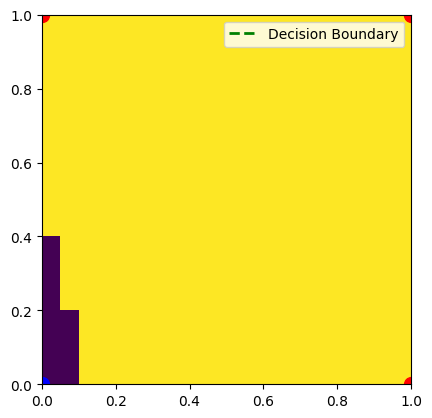

In [8]:
import matplotlib.pyplot as plt
import random

input  = np.array(
          [[0,0],
          [0,1],
          [1,0],
          [1,1]])
target = np.array([
          0,
          1,
          1,
          1])

BIAS = -1.0

def plot_decision_boundary(W, inp, tgt):
    x = np.arange(0.0, 1.0, 0.05)
    y = np.arange(1.0, 0.0, -0.05)
    
    xx, yy = np.meshgrid(x, y)
    
    output = W[0]*xx + W[1]*yy + W[2]*BIAS
    fig, ax = plt.subplots(1,1)
    
    ax.imshow(output>=0.0, extent=[0,1,0,1])

    for point, t in zip(inp, tgt):
        color = 'ro' if t == 1 else 'bo'
        plt.plot(point[0], point[1], color, markersize=10)
        
    if abs(W[1]) > 1e-5:
        x_line = np.array([0, 1])
        y_line = (W[2] - W[0]*x_line) / W[1]
        mask = (y_line >= -1) & (y_line <= 2)
        plt.plot(x_line[mask], y_line[mask], 'g--', linewidth=2, label='Decision Boundary')
        plt.legend()
    plt.show()

def pred(W, inp):
    num_samples = inp.shape[0]
    inp_ext = np.append(inp, -1 * np.ones((num_samples, 1)), axis=1)
    pred = []
    for i in range(num_samples):
        activation = np.dot(W, inp_ext[i])
        y_pred = 1 if activation >= 0.0 else 0
        pred.append(y_pred)
    return np.array(pred)

def perceptron(inp, tgt, alpha=0.01, err_target=0.001):
  num_dat = len(tgt)
  inp_dim = len(inp[0])+1

  inp = np.append(inp, BIAS*np.ones([num_dat,1]), axis=1)

  W = (np.random.rand(inp_dim)-0.5)

  n = 0
  error = math.inf
  while error > err_target:
    order = np.arange(num_dat)
    np.random.shuffle(order)
    total_error = 0.0

    for i in order:

      # 1.1. activate output unit : don't forget to apply the step function!
        activation = np.dot(W, inp[i])
        y_pred = 1 if activation >= 0.0 else 0
      # 1.2. compute error
        error_i = tgt[i] - y_pred
      # 1.3. adjust weight, based on the error
        W = W + alpha * error_i * inp[i]
      # 1.4. keep sum of total_error during this epoch
      # total_error = total_error + absolute value of error from 1.2
        total_error += abs(error_i)
    # 2. compute error for the epoch as the mean error from the current epoch
    # error = total_error / number of samples
    error = total_error / num_dat
    # increment epoch count
    n = n + 1
    if n == 500:
        error = 0.00001

  # Done with training
  print('number of epochs = '+str(n))
  print('average error = '+str(error))

  return W


W = perceptron(input, target, 0.01, 0.001)

print('\n\nTesting plot_decision_boundary')
print(W)
plot_decision_boundary(W, input, target)




Or Test
number of epochs = 140
average error = 0.0
[0.26073488 0.35720672 0.25921473]
input: [0 0] -> predictide: 0
input: [0 1] -> predictide: 1
input: [1 0] -> predictide: 1
input: [1 1] -> predictide: 1


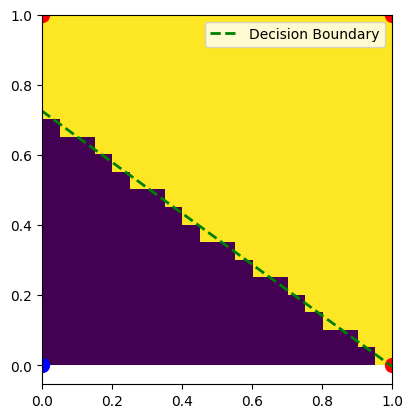



And Test
number of epochs = 273
average error = 0.0
[0.00633184 0.15913362 0.15948952]
input: [0 0] -> predictide: 0
input: [0 1] -> predictide: 0
input: [1 0] -> predictide: 0
input: [1 1] -> predictide: 1


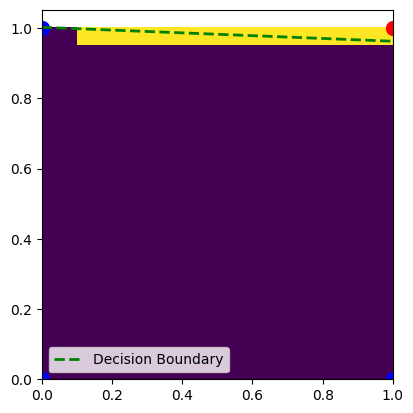



XOR Test
number of epochs = 500
average error = 1e-05
[0.18169973 0.18264207 0.18233025]
input: 1 -> predictide: 0
input: 1 -> predictide: 1


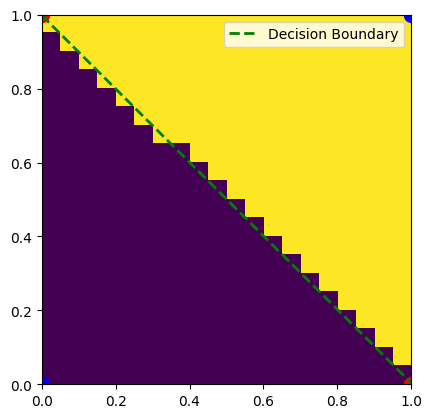

In [19]:
#or
input  = np.array(
          [[0,0],
          [0,1],
          [1,0],
          [1,1]])
target = np.array([
          0,
          1,
          1,
          1])

BIAS = -1.0

print('\n\nOr Test')
W = perceptron(input, target, 0.001, 0.001)
print(W)
pred_or = pred(W, input)
for inp, pre in zip(input, pred_or):
    print(f"input: {inp} -> predictide: {pre}")
plot_decision_boundary(W, input, target)

#and
input  = np.array(
          [[0,0],
          [0,1],
          [1,0],
          [1,1]])
target = np.array([
          0,
          0,
          0,
          1])

BIAS = -1.0

print('\n\nAnd Test')
W = perceptron(input, target, 0.001, 0.001)
print(W)
pred_or = pred(W, input)
for inp, pre in zip(input, pred_or):
    print(f"input: {inp} -> predictide: {pre}")
plot_decision_boundary(W, input, target)


#xor
input  = np.array(
          [[0,0],
          [0,1],
          [1,0],
          [1,1]])
target = np.array([
          0,
          1,
          1,
          0])

BIAS = -1.0

print('\n\nXOR Test')
W = perceptron(input, target, 0.001, 0.001)
print(W)
pred_or = pred(W, input)
for inp, pre in zip(inp, pred_or):
    print(f"input: {inp} -> predictide: {pre}")
plot_decision_boundary(W, input, target)

# Gradient Descent




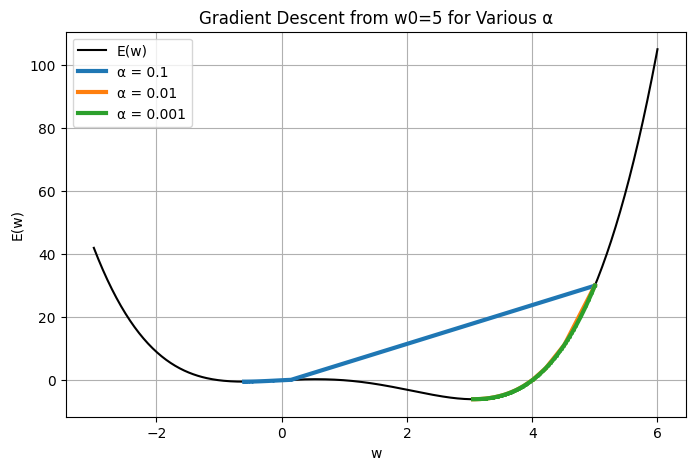

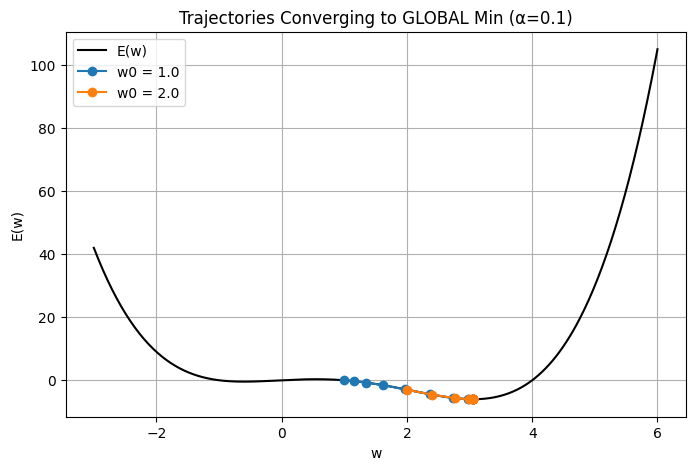

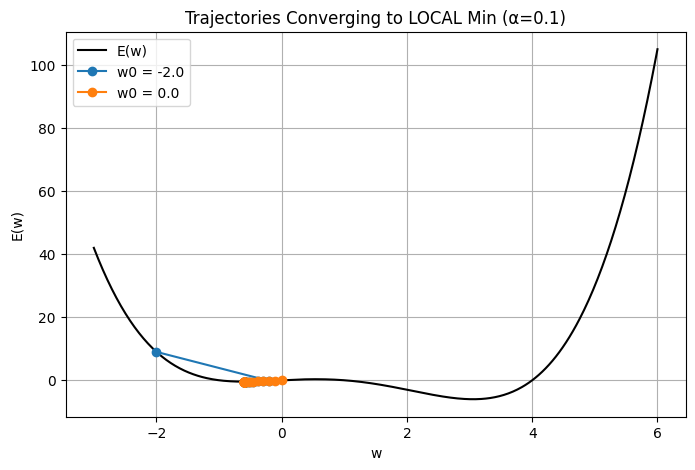

: 

In [ ]:
def E(w):
  '''
  implement this
  '''
  return 0.25 * w * (w + 1) * (w - 1) * (w - 4)

# 2. define derivative function
def dEdw(w):
  return w**3 - 3 * w ** 2 - .5 * w + 1

# 3. gradient descent
def gd(w0, alpha, tol=1e-6, max_iter=1000):
    w = w0
    path = [(w, E(w))]
    for _ in range(max_iter):
        grad = dEdw(w)
        if abs(grad) < tol:
            break
        w -= alpha * grad
        path.append((w, E(w)))
    return np.array(path)

w_grid = np.linspace(-3, 6, 500)
E_grid = E(w_grid)

# --- Part 1: Different learning rates (initial w0 = 5) ---
alphas = [0.1, 0.01, 0.001]
plt.figure(figsize=(8, 5))
plt.plot(w_grid, E_grid, 'k-', label='E(w)')

for alpha in alphas:
    traj = gd(5.0, alpha)
    plt.plot(traj[:,0], traj[:,1], marker='o', markersize = 1, linewidth = 3, label=f'α = {alpha}')

plt.title('Gradient Descent from w0=5 for Various α')
plt.xlabel('w')
plt.ylabel('E(w)')
plt.legend()
plt.grid(True)
plt.show()

# --- Part 2: Two initials leading to GLOBAL minimum (α = 0.1) ---
alpha2 = 0.1
inits_global = [1.0, 2.0]
plt.figure(figsize=(8, 5))
plt.plot(w_grid, E_grid, 'k-', label='E(w)')

for w0 in inits_global:
    traj = gd(w0, alpha2)
    plt.plot(traj[:,0], traj[:,1], marker='o', label=f'w0 = {w0}')

plt.title('Trajectories Converging to GLOBAL Min (α=0.1)')
plt.xlabel('w')
plt.ylabel('E(w)')
plt.legend()
plt.grid(True)
plt.show()

# --- Part 3: Two initials leading to LOCAL minimum (α = 0.1) ---
inits_local = [-2.0, 0.0]
plt.figure(figsize=(8, 5))
plt.plot(w_grid, E_grid, 'k-', label='E(w)')

for w0 in inits_local:
    traj = gd(w0, alpha2)
    plt.plot(traj[:,0], traj[:,1], marker='o', label=f'w0 = {w0}')

plt.title('Trajectories Converging to LOCAL Min (α=0.1)')
plt.xlabel('w')
plt.ylabel('E(w)')
plt.legend()
plt.grid(True)
plt.show()